In [ ]:
import pandas as pd
import numpy as np
from dash import Dash, dcc, html, dash_table, Input, Output, State
import plotly.express as px
import plotly.graph_objects as go

# ----- Load data -----
# Expects a CSV with columns: country,region,year,happiness_score,gdp_per_capita,social_support,healthy_life_expectancy,freedom,generosity,perceptions_of_corruption
DF_PATH = "happiness_combined.csv"

def load_data(path=DF_PATH):
    df = pd.read_csv(path)
    # Ensure proper dtypes
    df['year'] = df['year'].astype(int)
    # Some dashboards prefer log GDP — keep original but allow using it in plots
    return df

df = load_data()

YEARS = sorted(df['year'].unique())
REGIONS = sorted(df['region'].dropna().unique())
COUNTRIES = sorted(df['country'].unique())

# ----- App -----
app = Dash(__name__, suppress_callback_exceptions=True)
server = app.server

app.layout = html.Div([
    html.H2("Happiness Dashboard"),
    html.Div(id='kpi-row', style={'display':'flex','gap':'30px','alignItems':'center'}),

    html.Div([
        html.Div([
            html.Label("Año"),
            dcc.Dropdown(id='year-dropdown', options=[{'label':y,'value':y} for y in YEARS], value=YEARS[-1], clearable=False)
        ], style={'width':'200px','display':'inline-block','verticalAlign':'top'}),

        html.Div([
            html.Label("Región"),
            dcc.Dropdown(id='region-dropdown', options=[{'label':r,'value':r} for r in REGIONS], multi=True)
        ], style={'width':'300px','display':'inline-block','marginLeft':'20px'}),

        html.Div([
            html.Label("País(es)") ,
            dcc.Dropdown(id='country-dropdown', options=[{'label':c,'value':c} for c in COUNTRIES], multi=True)
        ], style={'width':'400px','display':'inline-block','marginLeft':'20px'}),

        html.Div([
            html.Label("Umbral felicidad"),
            dcc.Slider(id='happiness-slider', min=0, max=10, step=0.1, value=5,
                       marks={0:'0',2.5:'2.5',5:'5',7.5:'7.5',10:'10'})
        ], style={'width':'600px','marginTop':'10px'})
    ], style={'padding':'10px','borderBottom':'1px solid #ddd'}),

    # Graphs grid
    html.Div([
        html.Div(dcc.Graph(id='scatter-gdp-happiness'), style={'width':'48%','display':'inline-block'}),
        html.Div(dcc.Graph(id='bar-top-bottom'), style={'width':'48%','display':'inline-block','float':'right'})
    ]),

    html.Div([
        html.Div(dcc.Graph(id='line-evolution'), style={'width':'100%','display':'inline-block'}),
    ]),

    html.Div([
        html.Div(dcc.Graph(id='corr-heatmap'), style={'width':'100%','display':'inline-block'}),
    ]),

    html.H4("Datos (tabla)", style={'marginTop':'20px'}),
    dash_table.DataTable(
        id='table',
        columns=[{"name": i, "id": i} for i in df.columns],
        page_size=12,
        filter_action='native',
        sort_action='native',
        row_selectable='multi',
        export_format='csv',
    ),

    html.Div(id='hidden-div', style={'display':'none'})
])

# ----- Callbacks -----

@app.callback(
    Output('kpi-row','children'),
    Input('year-dropdown','value'),
    Input('region-dropdown','value'),
    Input('happiness-slider','value')
)
def update_kpis(year, regions, threshold):
    dff = df[df['year']==year]
    if regions:
        dff = dff[dff['region'].isin(regions)]
    avg = round(dff['happiness_score'].mean(),3) if not dff.empty else 'n/a'
    count = len(dff)
    top1 = dff.sort_values('happiness_score',ascending=False).head(1)
    top1_name = top1['country'].iloc[0] if not top1.empty else 'n/a'
    above = int((dff['happiness_score']>threshold).sum())
    return [
        html.Div([html.H5('Promedio felicidad'), html.H3(str(avg))], style={'padding':'8px','border':'1px solid #ddd','borderRadius':'6px'}),
        html.Div([html.H5('# países (filtro)'), html.H3(str(count))], style={'padding':'8px','border':'1px solid #ddd','borderRadius':'6px'}),
        html.Div([html.H5('Top 1'), html.H3(top1_name)], style={'padding':'8px','border':'1px solid #ddd','borderRadius':'6px'}),
        html.Div([html.H5('Por encima umbral'), html.H3(str(above))], style={'padding':'8px','border':'1px solid #ddd','borderRadius':'6px'})
    ]


@app.callback(
    Output('scatter-gdp-happiness','figure'),
    Input('year-dropdown','value'),
    Input('region-dropdown','value'),
    Input('happiness-slider','value')
)
def update_scatter(year, regions, threshold):
    dff = df[df['year']==year]
    if regions:
        dff = dff[dff['region'].isin(regions)]
    fig = px.scatter(dff, x='gdp_per_capita', y='happiness_score', hover_name='country',
                     size_max=12)
    # add simple trendline (using numpy polyfit)
    if len(dff)>=2 and dff['gdp_per_capita'].notna().sum()>1:
        x = dff['gdp_per_capita'].values
        y = dff['happiness_score'].values
        m,b = np.polyfit(x,y,1)
        xs = np.linspace(x.min(), x.max(), 100)
        fig.add_traces(go.Scatter(x=xs, y=m*xs+b, mode='lines', name='trend'))
    fig.update_layout(title=f'PIB per cápita vs Felicidad — {year}')
    # highlight above threshold
    fig.update_traces(marker=dict(opacity=0.8))
    return fig


@app.callback(
    Output('bar-top-bottom','figure'),
    Input('year-dropdown','value'),
    Input('region-dropdown','value')
)
def update_bar(year, regions):
    dff = df[df['year']==year]
    if regions:
        dff = dff[dff['region'].isin(regions)]
    top10 = dff.sort_values('happiness_score', ascending=False).head(10)
    bot10 = dff.sort_values('happiness_score', ascending=True).head(10)
    fig = go.Figure()
    fig.add_trace(go.Bar(x=top10['happiness_score'][::-1], y=top10['country'][::-1], orientation='h', name='Top 10'))
    fig.add_trace(go.Bar(x=bot10['happiness_score'], y=bot10['country'], orientation='h', name='Bottom 10'))
    fig.update_layout(title=f'Top 10 / Bottom 10 — {year}', barmode='group', height=500)
    return fig


@app.callback(
    Output('line-evolution','figure'),
    Input('country-dropdown','value'),
    Input('region-dropdown','value')
)
def update_line(countries, regions):
    dff = df.copy()
    if regions and not countries:
        countries = dff[dff['region'].isin(regions)]['country'].unique().tolist()[:5]
    if not countries:
        countries = [dff['country'].iloc[0]]
    fig = go.Figure()
    for c in countries[:5]:
        dd = dff[dff['country']==c].sort_values('year')
        fig.add_trace(go.Scatter(x=dd['year'], y=dd['happiness_score'], mode='lines+markers', name=c))
    fig.update_layout(title='Evolución temporal — felicidad', xaxis_title='Año', yaxis_title='Happiness score')
    return fig


@app.callback(
    Output('corr-heatmap','figure'),
    Input('year-dropdown','value'),
    Input('region-dropdown','value')
)
def update_heatmap(year, regions):
    dff = df[df['year']==year]
    if regions:
        dff = dff[dff['region'].isin(regions)]
    numeric = dff[['happiness_score','gdp_per_capita','social_support','healthy_life_expectancy','freedom','generosity','perceptions_of_corruption']]
    if numeric.shape[0]<2:
        fig = go.Figure()
        fig.update_layout(title='No hay datos suficientes para correlación')
        return fig
    corr = numeric.corr()
    fig = px.imshow(corr, text_auto=True, aspect='auto', title=f'Correlaciones — {year}')
    return fig


@app.callback(
    Output('table','data'),
    Input('year-dropdown','value'),
    Input('region-dropdown','value'),
    Input('country-dropdown','value'),
    Input('happiness-slider','value')
)
def update_table(year, regions, countries, threshold):
    dff = df[df['year']==year]
    if regions:
        dff = dff[dff['region'].isin(regions)]
    if countries:
        dff = dff[dff['country'].isin(countries)]
    dff = dff[dff['happiness_score']>=threshold]
    return dff.to_dict('records')


if __name__ == '__main__':
    app.run(debug=True)

## Preguntas


<span style='color:#4285F4;'> 1. ¿Cómo varía el puntaje de felicidad por país en el año seleccionado?

El mapa de coropletas (map-happiness) evidencia una clara brecha global. La felicidad es alta en Norteamérica, Europa Occidental y la región de ANZ, mientras que los puntajes más bajos se concentran geográficamente en África Subsahariana y el Sur de Asia.

<span style='color:#4285F4;'>2. ¿Existe relación entre felicidad y PIB per cápita?

El gráfico de dispersión (scatter-gdp-happiness) y el mapa de calor (corr-heatmap) demuestran una relación positiva muy fuerte. A mayor PIB per cápita, mayor es la tendencia a un alto puntaje de felicidad, siendo el PIB uno de los predictores más robustos del bienestar.

<span style='color:#4285F4;'>3. ¿Qué top 10 países son más felices y cuáles los bottom 10 en el año?

El gráfico de barras (bar-top-bottom) muestra que los países Top 10 son consistentemente naciones ricas y estables (ej. Finlandia, Dinamarca) con alto soporte social. Los Bottom 10 son, por el contrario, países que sufren de pobreza extrema, conflictos o colapso institucional.

<span style='color:#4285F4;'>4. ¿Cómo ha evolucionado la felicidad a lo largo del tiempo en países seleccionados?

El gráfico de líneas (line-evolution) revela que las naciones estables mantienen puntajes altos y constantes. Sin embargo, en otros países se puede identificar la volatilidad y el impacto directo de crisis económicas, políticas o sociales, viendo caídas abruptas en sus puntajes.

<span style='color:#4285F4;'>5. ¿Qué regiones (o grupos) presentan mayor/menor felicidad promedio en el año?

El gráfico de barras por región (bar-region-avg) presenta una jerarquía clara: North America and ANZ y Western Europe tienen los promedios más altos. Sub-Saharan Africa y Southern Asia tienen los más bajos, mientras que Latin America destaca por un promedio medio-alto, superior al esperado por su PIB.

<span style='color:#4285F4;'>6. ¿Qué factor (apoyo social, salud, libertad, etc.) se asocia más con la felicidad (correlación)?

En los tres años (2017–2019), los factores “social_support” y “gdp_per_capita” muestran las correlaciones más altas con la felicidad (valores cercanos a 0.7–0.8), indicando que el apoyo social y el ingreso son los más determinantes.

<span style='color:#4285F4;'>7. ¿Qué países mejoran o empeoran más entre dos años elegidos?

Al comparar la evolución en el gráfico de líneas, se observa que algunos países mantienen estabilidad, mientras otros suben o bajan notablemente; los países nórdicos suelen mantenerse altos, mientras que algunos latinoamericanos muestran variaciones leves o descensos.

<span style='color:#4285F4;'>8. ¿Qué tan dispersa es la felicidad dentro de una región (boxplot por región)?

La dispersión entre países de una misma región es moderada: Europa muestra valores altos y poco dispersos, mientras que regiones como África o Asia presentan mayor variabilidad, reflejando desigualdad en condiciones de vida.

<span style='color:#4285F4;'>9. ¿El umbral de felicidad (slider) cómo cambia el conjunto de países que lo superan?

Al mover el slider, el número de países sobre el umbral disminuye rápidamente a partir de 7 puntos; esto se refleja en los KPI “Por encima umbral” y en la tabla filtrada, mostrando que solo unos pocos países superan niveles altos de felicidad.

<span style='color:#4285F4;'>10. ¿Cuál es el perfil (valores de factores) de un país específico comparado con el promedio regional?

Seleccionando un país en la tabla o dropdown, se observa que su nivel de apoyo social, salud y libertad puede compararse con el promedio regional; por ejemplo, Finlandia supera ampliamente el promedio de su región en casi todos los indicadores, mientras otros países quedan por debajo.


## Capturas Del Dash

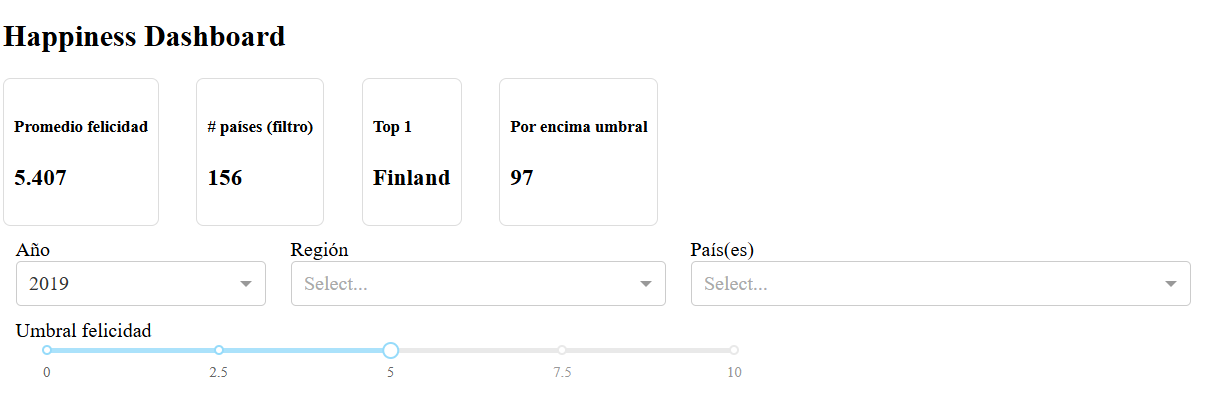

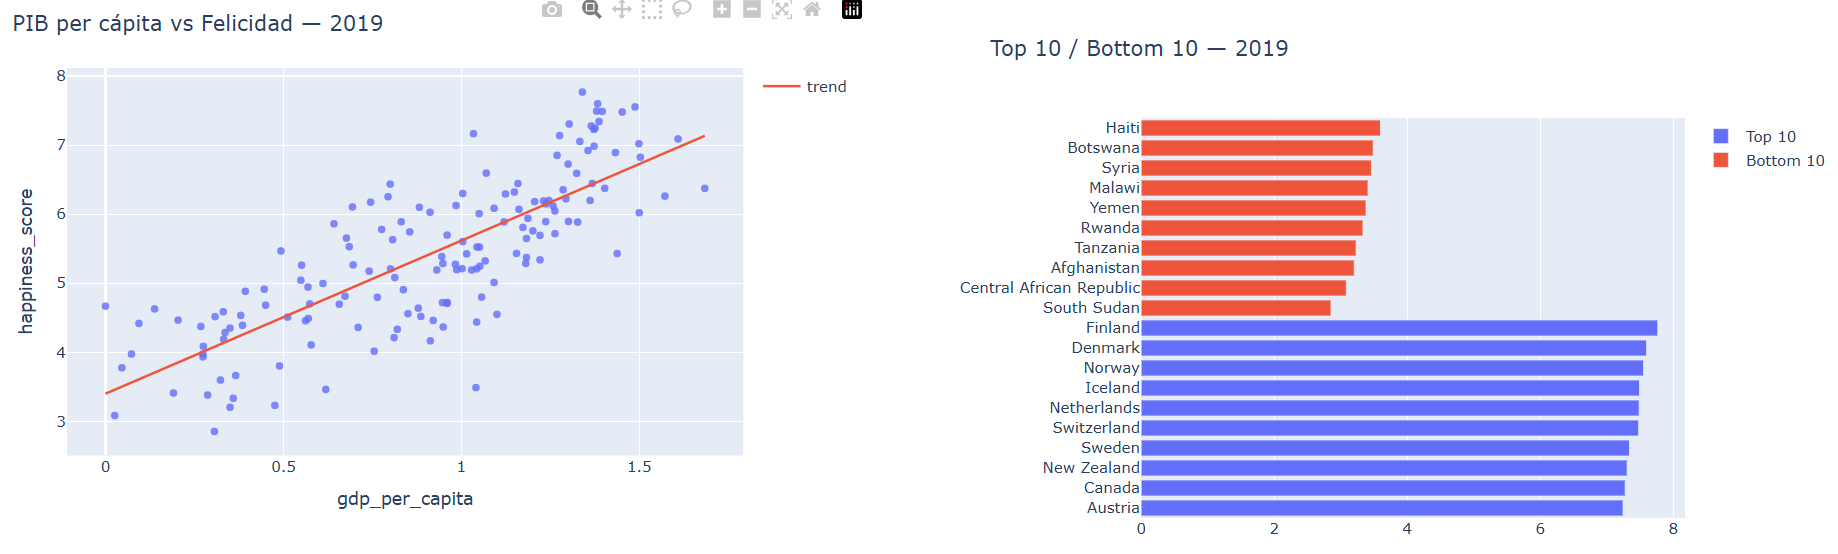

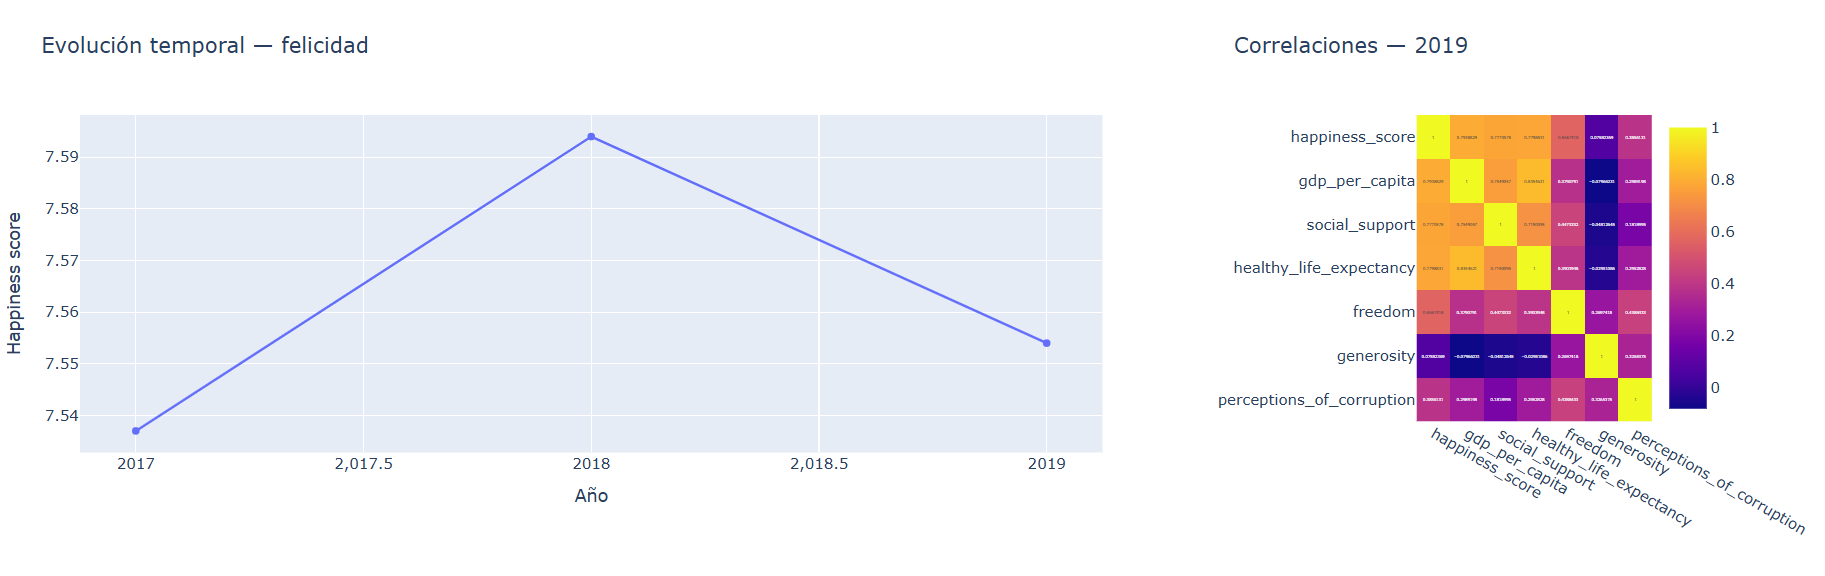

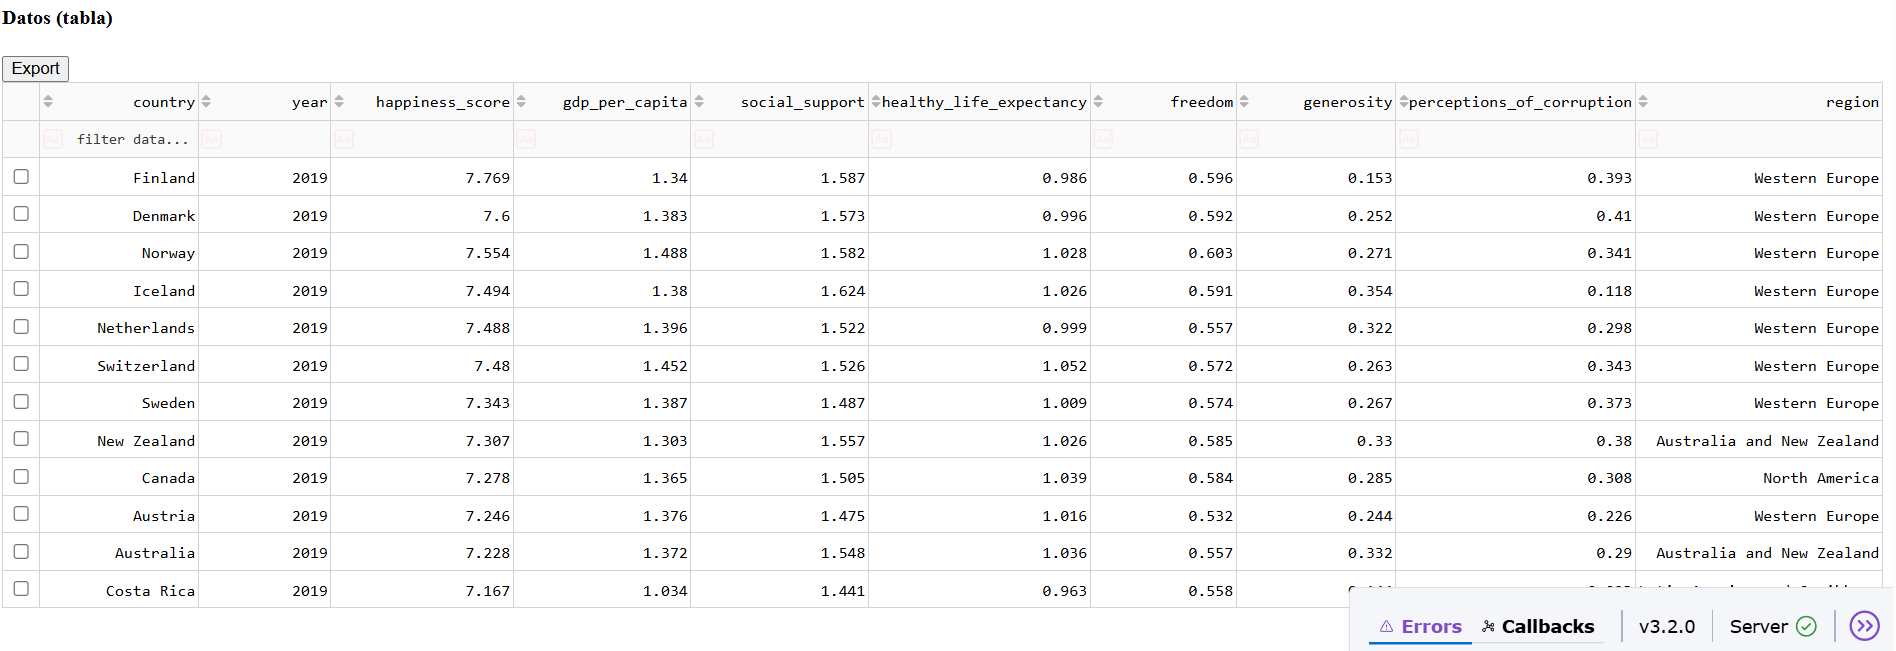